# Notebook 2 — Directional composite circadian-dysfunction score

### Why a different approach?
Notebook 1 showed three structural issues with the per-metric ±1 SD rule:
- both tails receive the same label (opposite biology mixed);
- labels disagree across metrics, so there is no coherent classification;
- dichotomising wastes power.

This notebook builds a **single, directional dysfunction score** from the circadian
metrics, splits old animals on that score, and compares behaviour — then cross-checks
the conclusion with a continuous correlation.

**Directionality (health → dysfunction):**
- `IS` ↓ = dysfunction → flip sign
- `IV` ↑ = dysfunction → keep sign
- `RA` ↓ = dysfunction → flip sign
- `Amplitude` ↓ = dysfunction → flip sign


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

sns.set_context("notebook")
sns.set_style("whitegrid")

REPO = Path.cwd().parent.parent  # notebook lives at poster_analysis/vulnerability_resilience_analysis/

# Circadian_raw has ID, PRE_POST, metrics, Age_new, Sex_new, Light_new
circ = pd.read_csv(REPO / "Circadian_raw.csv").rename(columns={"PRE.POST": "PRE_POST"})
metrics_base = ["IS", "IV", "RA", "Amplitude"]
wide = circ.pivot_table(
    index="ID", columns="PRE_POST", values=metrics_base
)
wide.columns = [f"{m}_{p.lower()}" for m, p in wide.columns]
wide = wide.reset_index()

grp = (
    circ[["ID", "Sex_new", "Age_new", "Light_new"]]
    .drop_duplicates(subset="ID")
    .reset_index(drop=True)
)
wide = wide.merge(grp, on="ID", how="left")

# Barnes — trial-6 endpoints + learning slope
barnes = pd.read_csv(REPO / "Barnes_clean.csv")
t6 = barnes[barnes["Trial"] == 6][["ID", "EntryZone_freq_new", "Q4"]].rename(
    columns={"EntryZone_freq_new": "barnes_entries_t6", "Q4": "barnes_Q4_pct"}
    # Q4 = target (goal) quadrant; Q1 = opposite quadrant. Per sex_age_effects.py.
    # Higher Q4 % = more time in the correct quadrant = better spatial memory.
)
slopes = pd.read_csv(REPO / "learning_slopes_per_mouse.csv")[["ID", "learning_slope"]]

# NOR
nor = pd.read_csv(REPO / "UCBAge_Novel_clean.csv").rename(columns={"Animal_ID": "ID"})
nor["DI_duration"] = (nor["N_obj_nose_duration_s"] - nor["F_obj_nose_duration_s"]) / (
    nor["N_obj_nose_duration_s"] + nor["F_obj_nose_duration_s"]
)
nor = nor[["ID", "DI_duration"]]

master = wide.merge(t6, on="ID", how="left").merge(slopes, on="ID", how="left").merge(
    nor, on="ID", how="left"
)

# FILTER TO OLD ANIMALS
old = master[master["Age_new"] == "Old"].copy().reset_index(drop=True)
print(f"Old animals: n = {len(old)}")
old.head()


Old animals: n = 40


,ID,Amplitude_post,Amplitude_pre,IS_post,IS_pre,IV_post,IV_pre,RA_post,RA_pre,Sex_new,Age_new,Light_new,barnes_entries_t6,barnes_Q4_pct,learning_slope,DI_duration
0,1,2.861,2.777,0.292,0.405,1.212,1.136,0.251,0.432,Male,Old,CTR,0.0,33.9755,0.011797,0.175988
1,4,1.860,2.976,0.259,0.520,0.899,1.188,0.279,0.370,Male,Old,CTR,0.0,44.2134,-0.065625,0.276134
2,6,2.668,2.086,0.492,0.549,1.343,1.617,0.469,0.801,Male,Old,ISF,1.0,48.3363,-0.020119,0.434378
3,7,0.627,0.787,0.082,0.078,1.762,1.163,0.023,0.052,Male,Old,CTR,5.0,42.0315,0.008642,0.421712
4,8,2.175,2.372,0.329,0.533,1.072,1.539,0.359,0.413,Male,Old,CTR,0.0,58.4939,0.054414,0.751609


## Step 1 — Per-metric distributions (same as Notebook 1) with Gaussian + Shapiro

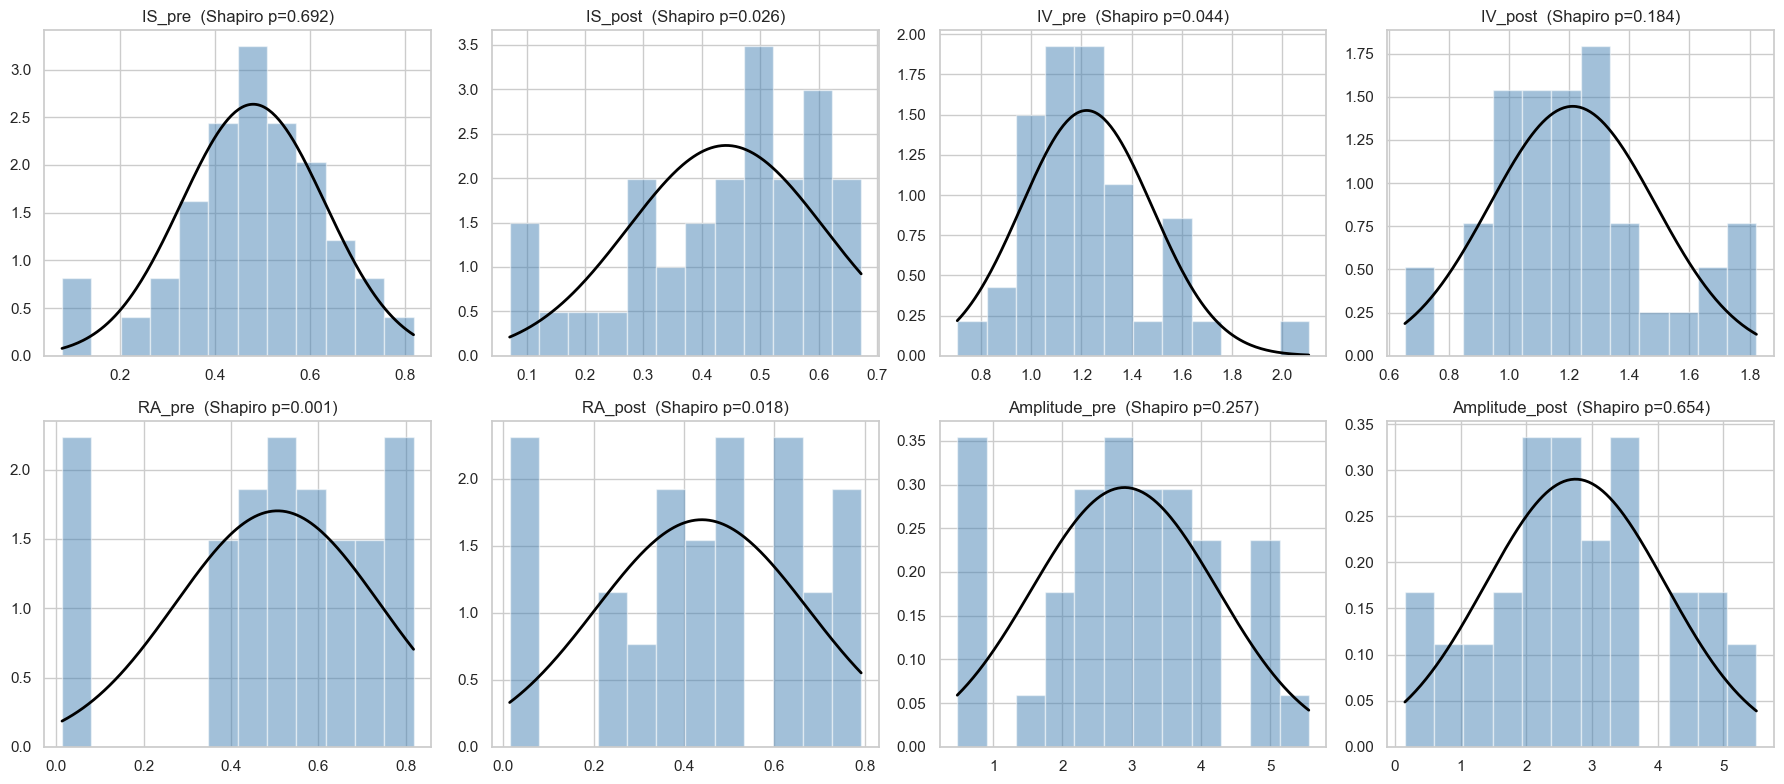

In [2]:
CIRC_METRICS = ['IS_pre', 'IS_post', 'IV_pre', 'IV_post', 'RA_pre', 'RA_post', 'Amplitude_pre', 'Amplitude_post']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, m in zip(axes.ravel(), CIRC_METRICS):
    x = old[m].dropna().values
    mu, sd = x.mean(), x.std(ddof=1)
    ax.hist(x, bins=12, density=True, alpha=0.5, color="steelblue",
            edgecolor="white")
    xs = np.linspace(x.min(), x.max(), 200)
    ax.plot(xs, stats.norm.pdf(xs, mu, sd), "k-", lw=2)
    W, p = stats.shapiro(x)
    ax.set_title(f"{m}  (Shapiro p={p:.3f})")
plt.tight_layout()
plt.show()


## Step 2 — Build the directional composite score

In [3]:
# Sign: +1 means "higher value = more dysfunction" (kept as-is after z-scoring);
#       -1 means "lower value = more dysfunction" (sign is flipped so higher z = worse).
DIRECTION = {
    "IS_pre": -1, "IS_post": -1,       # low IS = dysfunction
    "IV_pre": +1, "IV_post": +1,       # high IV = dysfunction
    "RA_pre": -1, "RA_post": -1,       # low RA = dysfunction
    "Amplitude_pre": -1, "Amplitude_post": -1,  # low amplitude = dysfunction
}

z = old[CIRC_METRICS].apply(lambda col: (col - col.mean()) / col.std(ddof=1))
for m, sign in DIRECTION.items():
    z[m] = sign * z[m]  # higher = more dysfunction

old["dysfunction_score"] = z.mean(axis=1)  # mean-z composite
old[["ID", "dysfunction_score"]].describe().round(3)


,ID,dysfunction_score
count,40.000,40.000
mean,44.075,0.000
std,29.369,0.815
min,1.000,-1.398
25%,18.750,-0.589
50%,36.500,-0.185
75%,73.250,0.210
max,96.000,1.842


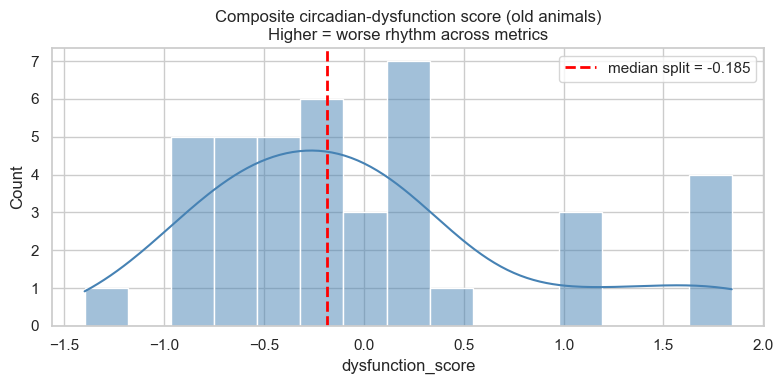

In [4]:
# Distribution of the composite score
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(old["dysfunction_score"], bins=15, kde=True, ax=ax, color="steelblue")
median = old["dysfunction_score"].median()
ax.axvline(median, color="red", ls="--", lw=2,
           label=f"median split = {median:.3f}")
ax.set_title("Composite circadian-dysfunction score (old animals)\n"
             "Higher = worse rhythm across metrics")
ax.legend()
plt.tight_layout()
plt.show()


### PCA cross-check — is the composite picking up the same signal as the first PC?

Explained variance ratio: [0.669 0.092 0.084]


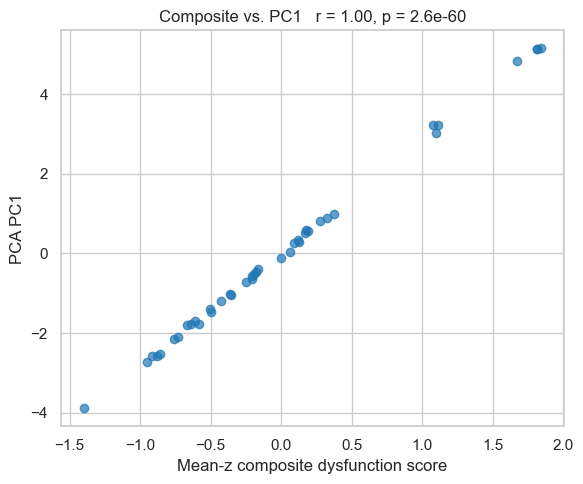

In [5]:
# Numpy-only PCA via SVD (no sklearn dependency).
X = z.values - z.values.mean(axis=0, keepdims=True)
U, S, Vt = np.linalg.svd(X, full_matrices=False)
scores = U * S              # principal component scores
explained_var = (S ** 2) / (X.shape[0] - 1)
explained_ratio = explained_var / explained_var.sum()
old["PC1"] = scores[:, 0]
print("Explained variance ratio:", np.round(explained_ratio[:3], 3))

# Sign of PC1 is arbitrary — align it with the composite so the scatter is interpretable.
if np.corrcoef(old["dysfunction_score"], old["PC1"])[0, 1] < 0:
    old["PC1"] = -old["PC1"]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(old["dysfunction_score"], old["PC1"], alpha=0.7)
r, p = stats.pearsonr(old["dysfunction_score"], old["PC1"])
ax.set_xlabel("Mean-z composite dysfunction score")
ax.set_ylabel("PCA PC1")
ax.set_title(f"Composite vs. PC1   r = {r:.2f}, p = {p:.2g}")
plt.tight_layout()
plt.show()


A strong |r| between the mean-z composite and PC1 is reassuring: the composite is
capturing the same dominant axis of variation that an unsupervised PCA finds. If the
two disagree you would want to inspect component loadings before trusting the
composite.

## Step 3 — Split old animals into resilient (low) vs vulnerable (high) by median

In [6]:
thr = old["dysfunction_score"].median()
old["group"] = np.where(old["dysfunction_score"] > thr, "vulnerable", "resilient")
old["group"].value_counts()


group
vulnerable    20
resilient     20
Name: count, dtype: int64

## Step 4 — Compare behaviour between groups

In [7]:
from scipy.stats import mannwhitneyu

def cohens_d(a, b):
    a, b = np.asarray(a), np.asarray(b)
    na, nb = len(a), len(b)
    sp = np.sqrt(((na-1)*a.var(ddof=1) + (nb-1)*b.var(ddof=1)) / (na+nb-2))
    return (a.mean() - b.mean()) / sp if sp > 0 else np.nan

def boot_ci_d(a, b, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    ds = np.empty(n_boot)
    for i in range(n_boot):
        ai = rng.choice(a, size=len(a), replace=True)
        bi = rng.choice(b, size=len(b), replace=True)
        ds[i] = cohens_d(ai, bi)
    return np.nanpercentile(ds, [2.5, 97.5])

BEHAV = [("barnes_entries_t6", "Barnes T6 entries"),
         ("learning_slope", "Barnes learning slope"),
         ("DI_duration", "NOR Discrimination Index")]

rows = []
for bm, bm_label in BEHAV:
    vul = old.loc[old["group"] == "vulnerable", bm].dropna().values
    res = old.loc[old["group"] == "resilient",  bm].dropna().values
    if len(vul) < 2 or len(res) < 2:
        continue
    U, p = mannwhitneyu(vul, res, alternative="two-sided")
    d = cohens_d(vul, res)
    lo, hi = boot_ci_d(vul, res)
    rows.append({"behaviour": bm_label,
                 "n_vul": len(vul), "n_res": len(res),
                 "mean_vul": vul.mean(), "mean_res": res.mean(),
                 "Cohen_d": d, "d_95CI_low": lo, "d_95CI_high": hi,
                 "MWU_p": p})
comp = pd.DataFrame(rows).round(3)
comp


,behaviour,n_vul,n_res,mean_vul,mean_res,Cohen_d,d_95CI_low,d_95CI_high,MWU_p
0,Barnes T6 entries,20,18,2.350,2.222,0.042,-0.748,0.548,0.393
1,Barnes learning slope,20,18,0.033,0.035,-0.027,-0.742,0.603,0.965
2,NOR Discrimination Index,20,16,0.553,0.468,0.286,-0.516,0.954,0.762


/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_75679/1496773453.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=old, x="group", y=bm, order=["resilient", "vulnerable"],
/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_75679/1496773453.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=old, x="group", y=bm, order=["resilient", "vulnerable"],
/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_75679/1496773453.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=old, x="group", y=bm, order=["resi

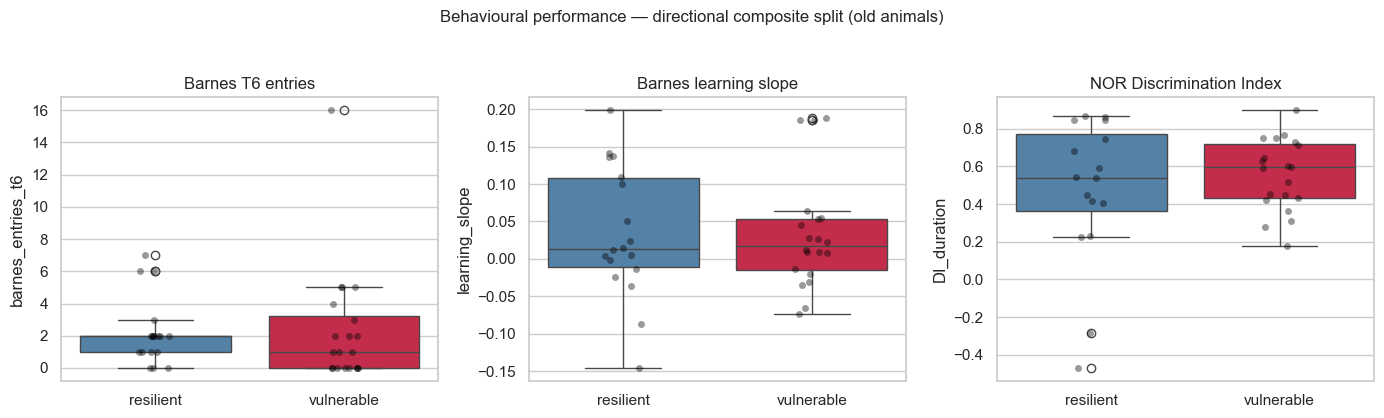

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (bm, bm_label) in zip(axes, BEHAV):
    sns.boxplot(data=old, x="group", y=bm, order=["resilient", "vulnerable"],
                ax=ax, palette=["steelblue", "crimson"])
    sns.stripplot(data=old, x="group", y=bm, order=["resilient", "vulnerable"],
                  ax=ax, color="black", alpha=0.4)
    ax.set_title(bm_label)
    ax.set_xlabel("")
plt.suptitle("Behavioural performance — directional composite split (old animals)",
             y=1.04, fontsize=12)
plt.tight_layout()
plt.show()


### Parametric (non-bootstrap) comparison

For direct side-by-side comparison with the bootstrap analysis above, here is the
same effect-size comparison computed without resampling: Cohen's *d* with parametric
95% CIs (Hedges approximation to the standard error) and a mean ± SEM bar chart per
outcome. If the two approaches agree, we know the effect-size estimates are not
bootstrap-dependent.


In [9]:
# Parametric (t-based) 95% CI for Cohen's d — Hedges & Olkin (1985) SE formula.
def d_param_ci(a, b):
    a, b = np.asarray(a), np.asarray(b)
    na, nb = len(a), len(b)
    d = cohens_d(a, b)
    se = np.sqrt((na + nb) / (na * nb) + d**2 / (2 * (na + nb - 2)))
    return d, d - 1.96 * se, d + 1.96 * se, se

rows_p = []
for bm, bm_label in BEHAV:
    vul = old.loc[old["group"] == "vulnerable", bm].dropna().values
    res = old.loc[old["group"] == "resilient",  bm].dropna().values
    if len(vul) < 2 or len(res) < 2:
        continue
    d, lo, hi, se = d_param_ci(vul, res)
    t, p = stats.ttest_ind(vul, res, equal_var=False)
    rows_p.append({"behaviour": bm_label,
                   "n_vul": len(vul), "n_res": len(res),
                   "Cohen_d": d, "d_95CI_low": lo, "d_95CI_high": hi,
                   "Welch_t": t, "Welch_p": p})
comp_param = pd.DataFrame(rows_p).round(3)
comp_param


,behaviour,n_vul,n_res,Cohen_d,d_95CI_low,d_95CI_high,Welch_t,Welch_p
0,Barnes T6 entries,20,18,0.042,-0.595,0.679,0.133,0.895
1,Barnes learning slope,20,18,-0.027,-0.664,0.610,-0.082,0.935
2,NOR Discrimination Index,20,16,0.286,-0.375,0.946,0.793,0.437


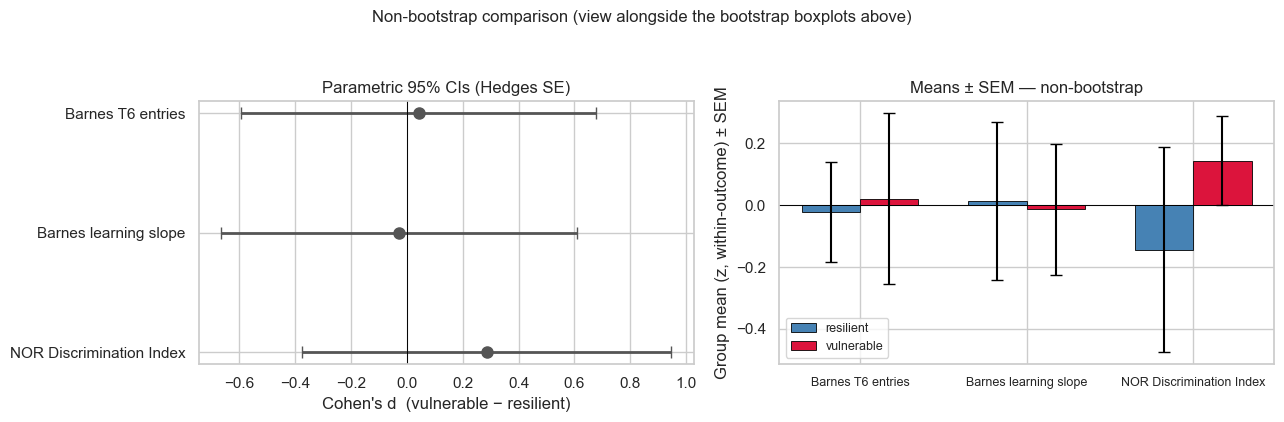

In [10]:
# Side-by-side visual: Cohen's d forest plot (parametric) + means ± SEM bar chart.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Left: forest plot of Cohen's d with parametric 95% CIs ---
ax = axes[0]
y = np.arange(len(comp_param))[::-1]  # top-to-bottom = first-to-last behaviour
for yi, row in zip(y, comp_param.itertuples()):
    color = "crimson" if (row.d_95CI_low * row.d_95CI_high) > 0 else "#555555"
    ax.errorbar(row.Cohen_d, yi,
                xerr=[[row.Cohen_d - row.d_95CI_low],
                      [row.d_95CI_high - row.Cohen_d]],
                fmt="o", color=color, ecolor=color, capsize=4, lw=2, ms=8)
ax.axvline(0, color="black", lw=0.7)
ax.set_yticks(y)
ax.set_yticklabels(comp_param["behaviour"])
ax.set_xlabel("Cohen's d  (vulnerable − resilient)")
ax.set_title("Parametric 95% CIs (Hedges SE)")

# --- Right: mean ± SEM per group, per outcome ---
ax = axes[1]
n_out = len(BEHAV)
width = 0.35
xs = np.arange(n_out)
for offset, grp, color in [(-width/2, "resilient", "steelblue"),
                           (+width/2, "vulnerable", "crimson")]:
    means, sems = [], []
    for bm, _ in BEHAV:
        v = old.loc[old["group"] == grp, bm].dropna().values
        means.append(v.mean())
        sems.append(v.std(ddof=1) / np.sqrt(len(v)))
    # put them on a common axis by z-scoring each outcome across both groups
    # (so different-scaled outcomes share the axis)
    pass
# Because the three outcomes live on different scales, use z-score within outcome
# so the bar chart is readable on a single axis.
means_df = pd.DataFrame({
    grp: [old.loc[old["group"] == grp, bm].dropna().mean() for bm, _ in BEHAV]
    for grp in ["resilient", "vulnerable"]
}, index=[lbl for _, lbl in BEHAV])
sems_df = pd.DataFrame({
    grp: [old.loc[old["group"] == grp, bm].dropna().std(ddof=1) /
          np.sqrt(old.loc[old["group"] == grp, bm].dropna().size)
          for bm, _ in BEHAV]
    for grp in ["resilient", "vulnerable"]
}, index=[lbl for _, lbl in BEHAV])
# z-score each row by the pooled SD across both groups (readability only)
pooled_sd = pd.Series(
    [old[bm].dropna().std(ddof=1) for bm, _ in BEHAV],
    index=[lbl for _, lbl in BEHAV],
)
means_z = means_df.sub(means_df.mean(axis=1), axis=0).div(pooled_sd, axis=0)
sems_z  = sems_df.div(pooled_sd, axis=0)

for offset, grp, color in [(-width/2, "resilient", "steelblue"),
                           (+width/2, "vulnerable", "crimson")]:
    ax.bar(xs + offset, means_z[grp], width=width, yerr=sems_z[grp],
           color=color, label=grp, capsize=4, edgecolor="black", linewidth=0.6)
ax.axhline(0, color="black", lw=0.7)
ax.set_xticks(xs)
ax.set_xticklabels([lbl for _, lbl in BEHAV], fontsize=9)
ax.set_ylabel("Group mean (z, within-outcome) ± SEM")
ax.set_title("Means ± SEM — non-bootstrap")
ax.legend(loc="best", fontsize=9)

plt.suptitle("Non-bootstrap comparison (view alongside the bootstrap boxplots above)",
             y=1.05, fontsize=12)
plt.tight_layout()
plt.show()


The parametric Cohen's *d* estimates and CIs should overlap heavily with the bootstrap
ones reported above. If they do, that's reassurance that the near-zero group
differences are not a bootstrap artefact — they reflect the underlying data. If they
disagree, it usually means the sample distribution is skewed or has outliers, and the
bootstrap version is the more trustworthy of the two (no normality assumption).


## Step 5 — Robustness: continuous correlation between composite and behaviour

In [11]:
rows = []
for bm, bm_label in BEHAV:
    d = old[["dysfunction_score", bm]].dropna()
    rho, p = stats.spearmanr(d["dysfunction_score"], d[bm])
    rows.append({"behaviour": bm_label, "n": len(d),
                 "spearman_rho": round(rho, 3), "p": round(p, 4)})
pd.DataFrame(rows)


,behaviour,n,spearman_rho,p
0,Barnes T6 entries,38,-0.188,0.2582
1,Barnes learning slope,38,-0.046,0.7856
2,NOR Discrimination Index,36,0.047,0.7862


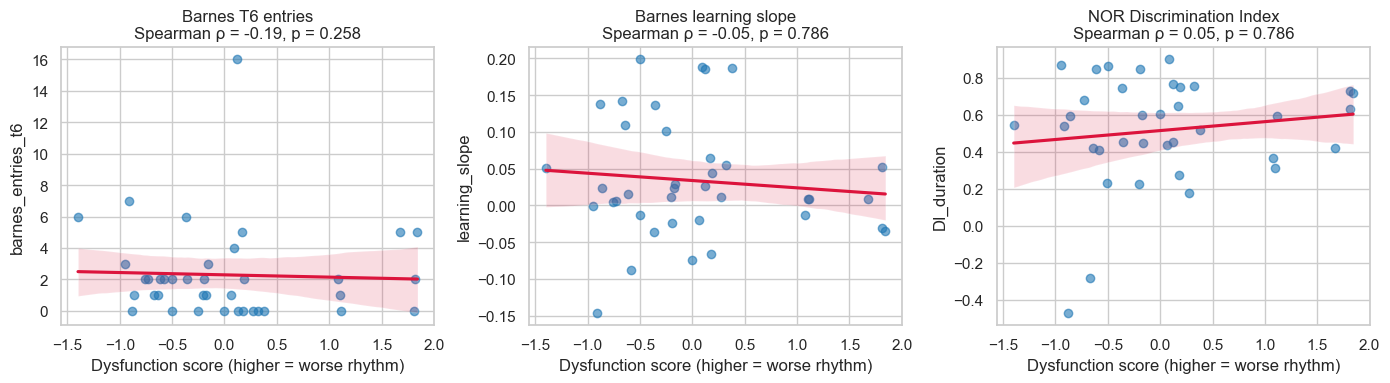

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (bm, bm_label) in zip(axes, BEHAV):
    d = old[["dysfunction_score", bm]].dropna()
    sns.regplot(data=d, x="dysfunction_score", y=bm, ax=ax,
                scatter_kws={"alpha": 0.6}, line_kws={"color": "crimson"})
    rho, p = stats.spearmanr(d["dysfunction_score"], d[bm])
    ax.set_title(f"{bm_label}\nSpearman ρ = {rho:.2f}, p = {p:.3f}")
    ax.set_xlabel("Dysfunction score (higher = worse rhythm)")
plt.tight_layout()
plt.show()


## When to use the composite vs. individual metrics

- **Composite-then-split** (this notebook) is the right first pass when you want a
  single label per animal and want to treat the circadian metrics as redundant
  indicators of one underlying construct (rhythm health).
- **Continuous correlation** is the gold standard when you do not need labels — it
  preserves all the power dichotomisation throws away.
- **Per-metric analysis** (Notebook 1 style) is only appropriate if each metric is
  hypothesised to carry *independent* biological meaning and you are prepared to
  correct for multiple comparisons.

**Sanity check to report to the PI:** if the composite split and the continuous
correlation point the same direction, the conclusion is robust. If they disagree,
neither is convincing and the story probably lives in a subset of metrics — which
argues for either PCA-based clustering or a pre-registered single-metric test, not
a post-hoc pick.

---
## Sex-stratified view — Old Males vs Old Females

The main analysis pooled 40 old animals. Because sex is the strongest predictor of
circadian phenotype in this cohort, and the Old-Male subgroup carries the
FDR-corrected locomotor deficit, we re-run the composite-split and continuous
correlation separately for Old Females and Old Males.


/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_75679/3771012776.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="group", y=bm, order=["resilient", "vulnerable"],
/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_75679/3771012776.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="group", y=bm, order=["resilient", "vulnerable"],
/var/folders/t3/h94sjlkj52n5m4ht71d3mwmw0000gn/T/ipykernel_75679/3771012776.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x="group", y=bm, order=["resi

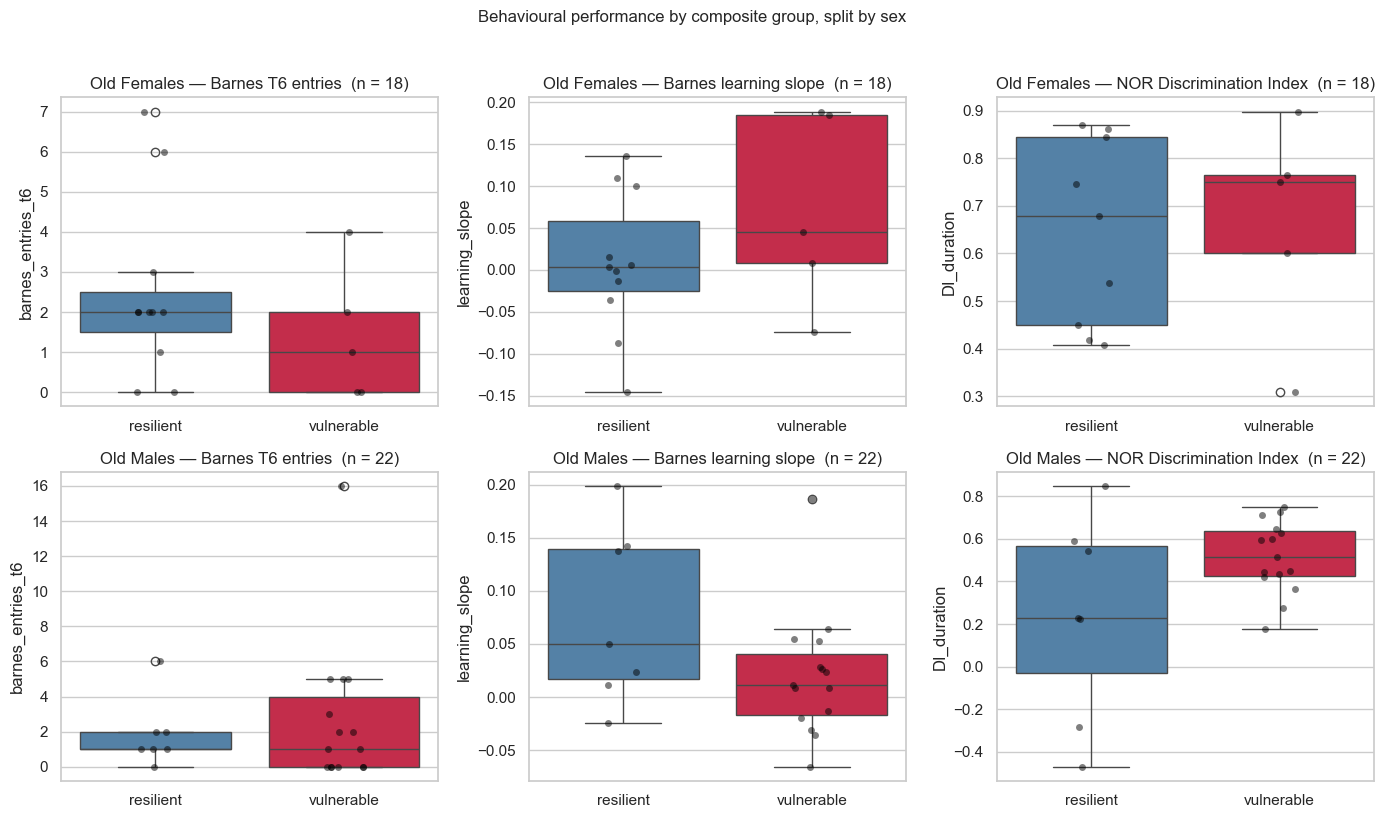

In [13]:
# 2 rows (Female, Male) x 3 columns (behavioural outcomes): composite-group boxplots
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for row_idx, sex in enumerate(["Female", "Male"]):
    sub = old[old["Sex_new"] == sex]
    for ax, (bm, bm_label) in zip(axes[row_idx], BEHAV):
        sns.boxplot(data=sub, x="group", y=bm, order=["resilient", "vulnerable"],
                    palette=["steelblue", "crimson"], ax=ax)
        sns.stripplot(data=sub, x="group", y=bm, order=["resilient", "vulnerable"],
                      color="black", alpha=0.5, ax=ax)
        ax.set_title(f"Old {sex}s — {bm_label}  (n = {len(sub)})")
        ax.set_xlabel("")
plt.suptitle("Behavioural performance by composite group, split by sex",
             y=1.02, fontsize=12)
plt.tight_layout(); plt.show()


Spearman correlations between dysfunction score and each behaviour, by sex:

  Barnes T6 entries         Female:  ρ = -0.422, p = 0.104
  Barnes T6 entries         Male  :  ρ = -0.069, p = 0.760
  Barnes learning slope     Female:  ρ = +0.456, p = 0.076
  Barnes learning slope     Male  :  ρ = -0.423, p = 0.050
  NOR Discrimination Index  Female:  ρ = -0.068, p = 0.817
  NOR Discrimination Index  Male  :  ρ = +0.391, p = 0.072


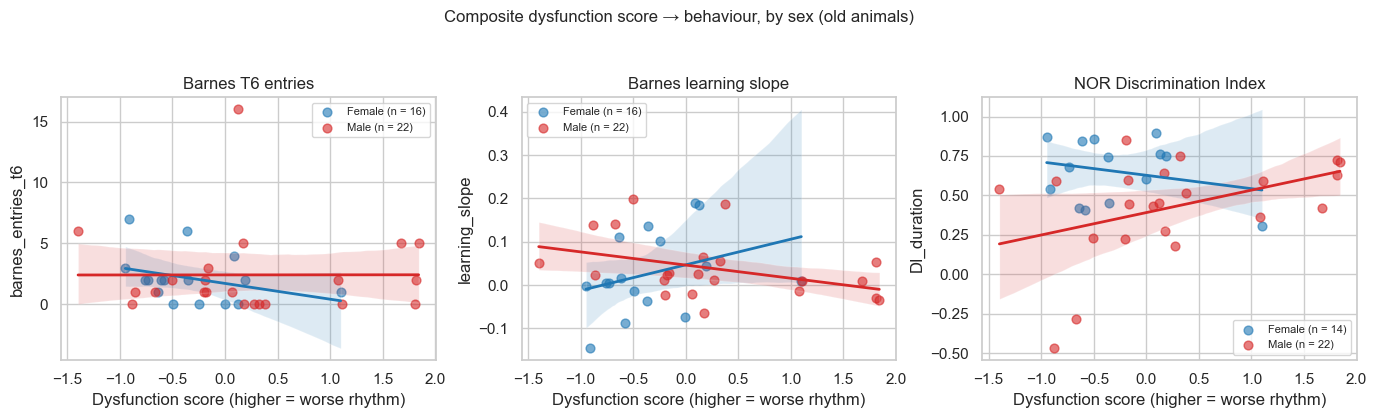

In [14]:
# Continuous correlations stratified by sex
print("Spearman correlations between dysfunction score and each behaviour, by sex:\n")
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (bm, bm_label) in zip(axes, BEHAV):
    for sex, color in [("Female", "#1f77b4"), ("Male", "#d62828")]:
        sub = old[old["Sex_new"] == sex].dropna(subset=["dysfunction_score", bm])
        if len(sub) < 5: continue
        sns.regplot(data=sub, x="dysfunction_score", y=bm, ax=ax,
                    scatter_kws={"alpha": 0.6, "color": color, "s": 40},
                    line_kws={"color": color, "lw": 2},
                    label=f"{sex} (n = {len(sub)})")
        rho, p = stats.spearmanr(sub["dysfunction_score"], sub[bm])
        print(f"  {bm_label:25s} {sex:6s}:  ρ = {rho:+.3f}, p = {p:.3f}")
    ax.set_title(bm_label)
    ax.set_xlabel("Dysfunction score (higher = worse rhythm)")
    ax.legend(fontsize=8)
plt.suptitle("Composite dysfunction score → behaviour, by sex (old animals)",
             y=1.04, fontsize=12)
plt.tight_layout(); plt.show()


**What to look for.** If the Male and Female regression lines diverge — same
predictor, opposite signs of slope — that is the signature of an interaction (sex
moderates the relationship). This is exactly the situation that motivated the
separate poster notebook focused on Old Males: the main candidate for a real
circadian–cognition signal is a sex-specific one, not a pooled one.
